# 04 Missing Phenotype Prediction

Этот ноутбук делает **финальное предсказание пропущенных фенотипов**:

1. **Выбирает лучшую модель** по результатам CV (самая высокая средняя корреляция)
2. **Обучает её на всех известных фенотипах** (все данные с non-NA y)
3. **Предсказывает y для записей с NA** — это и есть "genomic predictions" или "breeding values"

**Для кого**: для тех, кто хочет увидеть финальный результат — предсказанные значения для тех особей, у которых нет измеренного фенотипа.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

from gp_py.io import fn_load_genotype, fn_load_phenotype, fn_filter_genotype, fn_filter_phenotype, fn_merge_genotype_and_phenotype
from gp_py.cv import fn_cross_validation_within_population
from gp_py.schema import MergedData

## 1. Подготовка данных (полные, с пропусками)

In [2]:
DATA_DIR = Path("../inst/exec_Rscript/input")

G = fn_load_genotype(str(DATA_DIR / "test_geno.Rds"))
list_pheno = fn_load_phenotype(str(DATA_DIR / "test_pheno.tsv"))

# Фильтрация
Gf = fn_filter_genotype(G)
phf = fn_filter_phenotype(list_pheno)
merged = fn_merge_genotype_and_phenotype(Gf, phf)

print(f"Общий размер после merge: {merged.G.shape}")

known_mask = merged.y.notna()
missing_mask = merged.y.isna()

print(f"  Известные фенотипы: {known_mask.sum()}")
print(f"  Пропущенные (будут предсказаны): {missing_mask.sum()}")

Общий размер после merge: (500, 1000)
  Известные фенотипы: 475
  Пропущенные (будут предсказаны): 25


## 2. Запуск CV для выбора лучшей модели

In [3]:
# Данные только с известными фенотипами для CV
merged_known = MergedData(
    G=merged.G.loc[known_mask].copy(),
    y=merged.y.loc[known_mask].copy(),
    pop=merged.pop.loc[known_mask].copy(),
    trait_name=merged.trait_name,
)

# CV
cv_results = fn_cross_validation_within_population(
    merged_known,
    n_folds=3,
    n_reps=2,
    vec_models_to_test=(
        "ridge", "lasso", "elastic_net",
        # "Bayes_A", "Bayes_B", "Bayes_C", 
        "gBLUP",
        "SVR", "RandomForest",
        "XGBoost", "LightGBM",  # требуют: uv sync --extra ml
    ),
    bool_parallel=False,
    bayes_backend="native",
    verbose=False
)

metrics_df = cv_results["METRICS_WITHIN_POP"]
print("CV результаты:")
print(metrics_df.groupby("model")["corr"].mean().sort_values(ascending=False))

/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:715: UserWarning: Using deprecated variance components format
  warnings.warn("Using deprecated variance components format")
/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.571e-02, tolerance: 5.877e-02
  model = cd_fast.enet_coordinate_descent(
/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed

CV результаты:
model
elastic_net     0.652147
lasso           0.651401
LightGBM        0.558574
XGBoost         0.535900
ridge           0.530135
RandomForest    0.528789
SVR             0.505780
gBLUP           0.336200
Name: corr, dtype: float64


/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3. Выбор лучшей модели

In [4]:
# Лучшая модель по средней корреляции
model_perf = metrics_df.groupby("model")["corr"].mean()
best_model = model_perf.idxmax()
best_corr = model_perf.max()

print("=== Лучшая модель ===")
print(f"  Модель: {best_model}")
print(f"  Средняя корреляция на CV: {best_corr:.4f}")

=== Лучшая модель ===
  Модель: elastic_net
  Средняя корреляция на CV: 0.6521


## 4. Финальное обучение и предсказание

In [5]:
from gp_py.cv import MODEL_REGISTRY

# Используем центральный MODEL_REGISTRY — он включает ВСЕ модели:
#   ridge, lasso, elastic_net, Bayes_A/B/C, gBLUP,
#   SVR, RandomForest, XGBoost, LightGBM
# (XGBoost/LightGBM требуют: uv sync --extra ml)
print("Доступные модели:", list(MODEL_REGISTRY.keys()))

fn_best = MODEL_REGISTRY[best_model]

# Индексы: правильные булевы маски
train_idx = list(merged.y.dropna().index)
missing_idx = list(merged.y[merged.y.isna()].index)

print(f"Обучаем {best_model} на {len(train_idx)} записях...")
print(f"Предсказываем для {len(missing_idx)} записей с пропусками...")

# Финальное предсказание
result = fn_best(
    merged,
    vec_idx_training=train_idx,
    vec_idx_validation=missing_idx,
    other_params={"bayes_backend": "native"},
    verbose=False
)

print("Готово!")

Доступные модели: ['ridge', 'lasso', 'elastic_net', 'Bayes_A', 'Bayes_B', 'Bayes_C', 'gBLUP', 'SVR', 'RandomForest', 'XGBoost', 'LightGBM']
Обучаем elastic_net на 475 записях...
Предсказываем для 25 записей с пропусками...
Готово!


## 5. Результаты предсказаний

In [6]:
pred_df = result["df_y_validation"]
print("=== Предсказанные фенотипы (GENOMIC_PREDICTIONS) ===")
print(f"Число предсказаний: {len(pred_df)}")
print(f"\nПервые 10 записей:")
print(pred_df.head(10).to_string())

print(f"\nСтатистика предсказаний:")
print(f"  Min: {pred_df['y_pred'].min():.4f}")
print(f"  Max: {pred_df['y_pred'].max():.4f}")
print(f"  Mean: {pred_df['y_pred'].mean():.4f}")
print(f"  Std: {pred_df['y_pred'].std():.4f}")

=== Предсказанные фенотипы (GENOMIC_PREDICTIONS) ===
Число предсказаний: 25

Первые 10 записей:
    id    pop  y_true    y_pred
0    9  pop_1     NaN  0.513456
1   30  pop_2     NaN  1.492195
2   68  pop_3     NaN  0.224051
3   73  pop_1     NaN  0.510892
4   76  pop_3     NaN  0.497737
5   84  pop_2     NaN  0.226945
6  104  pop_1     NaN  0.323219
7  124  pop_2     NaN  1.224830
8  155  pop_2     NaN -0.116164
9  194  pop_1     NaN  0.964514

Статистика предсказаний:
  Min: -1.0924
  Max: 2.1602
  Mean: 0.3695
  Std: 0.8519


## 6. Визуализация предсказаний

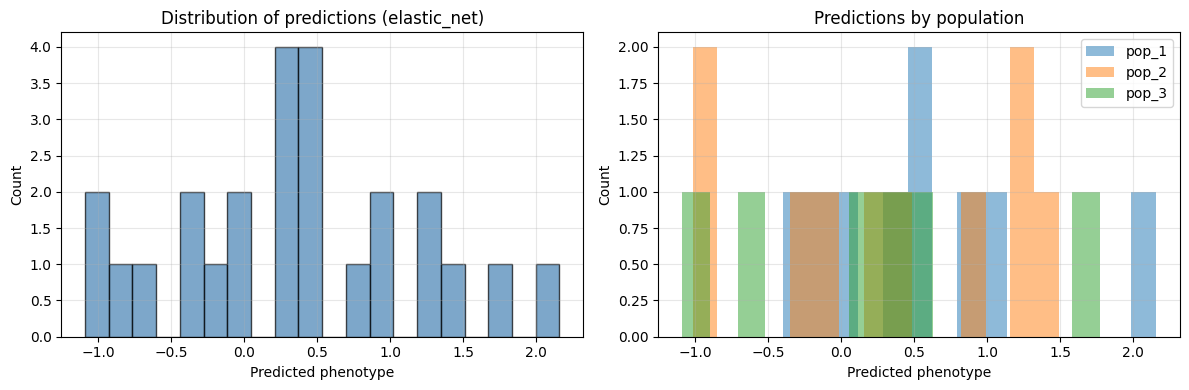

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма предсказаний
ax1 = axes[0]
ax1.hist(pred_df["y_pred"], bins=20, color="steelblue", alpha=0.7, edgecolor="black")
ax1.set_xlabel("Predicted phenotype")
ax1.set_ylabel("Count")
ax1.set_title(f"Distribution of predictions ({best_model})")
ax1.grid(True, alpha=0.3)

# По популяции
ax2 = axes[1]
for pop in pred_df["pop"].unique():
    subset = pred_df[pred_df["pop"] == pop]["y_pred"]
    ax2.hist(subset, bins=15, alpha=0.5, label=pop)
ax2.set_xlabel("Predicted phenotype")
ax2.set_ylabel("Count")
ax2.set_title("Predictions by population")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Итог

- Мы выбрали лучшую модель по CV (самая высокая средняя корреляция)
- Обучили её на всех записях с известным фенотипом
- Предсказали значения для записей с пропущенным фенотипом
- Получили **genomic predictions** — оценки breeding values для каждой особи

**Следующий шаг**: перейти к ноутбуку `05_parity_vs_r`, чтобы сравнить результаты Python-пайплайна с оригинальным R-пакетом.